# Cassava Leaf Disease Classification — EfficientNetB0
 

## 0. Install Dependencies

In [ ]:
%pip install tensorflow scikit-learn matplotlib seaborn -q

## 1. Imports & Reproducibility

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input  # ← critical: scales to [-1,1]
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, Callback
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.19.0
GPU available: False


## 2. Custom Callback — Stop at 92% Val Accuracy

In [2]:
class StopAt92(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get("val_accuracy", 0) >= 0.92:
            print(f"\n  ✅ Reached 92% val_accuracy at epoch {epoch + 1}. Stopping.")
            self.model.stop_training = True

## 3. Config — Update Paths Here

In [3]:

DATA_DIR    = r'C:\Users\Alfred\Desktop\data'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4
SEED        = 42

In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ── 1. Load all images from DATA_DIR ──────────────────────────────────────────
DATA_DIR = r'C:\Users\Alfred\Desktop\data'

data_list = []
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            data_list.append({
                'image_path': os.path.join(class_path, img_file),
                'label': class_name
            })

df = pd.DataFrame(data_list)

# ── 2. Dataset overview ───────────────────────────────────────────────────────
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print("\nClass distribution:")
counts = df['label'].value_counts()
for cls, count in counts.items():
    bar = '█' * (count // 50)
    print(f"  {cls:<45} {count:>5}  {bar}")

# ── 3. Train / Val split (80% train, 20% val, stratified) ────────────────────
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

print(f"\nSplit summary:")
print(f"  Train : {len(train_df)} images")
print(f"  Val   : {len(val_df)} images")
print(f"\nTrain class distribution:")
print(train_df['label'].value_counts().to_string())
print(f"\nVal class distribution:")
print(val_df['label'].value_counts().to_string())

Total images: 9726
Number of classes: 4

Class distribution:
  Cassava___brown_streak_disease                 2448  ████████████████████████████████████████████████
  Cassava___mosaic_disease                       2448  ████████████████████████████████████████████████
  Cassava___healthy                              2444  ████████████████████████████████████████████████
  Cassava___green_mottle                         2386  ███████████████████████████████████████████████

Split summary:
  Train : 7780 images
  Val   : 1946 images

Train class distribution:
label
Cassava___mosaic_disease          1958
Cassava___brown_streak_disease    1958
Cassava___healthy                 1955
Cassava___green_mottle            1909

Val class distribution:
label
Cassava___mosaic_disease          490
Cassava___brown_streak_disease    490
Cassava___healthy                 489
Cassava___green_mottle            477


## 4. Data Generators
> `preprocess_input` is the **key fix** vs the original maize script — it scales pixels to `[-1, 1]` as EfficientNet expects. Without this, the model trains on raw 0–255 values and struggles to converge.

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Classes : {train_data.class_indices}")
print(f"Train   : {train_data.samples} images")
print(f"Val     : {val_data.samples} images")

Found 7780 validated image filenames belonging to 4 classes.
Found 1946 validated image filenames belonging to 4 classes.
Classes : {'Cassava___brown_streak_disease': 0, 'Cassava___green_mottle': 1, 'Cassava___healthy': 2, 'Cassava___mosaic_disease': 3}
Train   : 7780 images
Val     : 1946 images


## 5. Class Weights (computed dynamically)

In [31]:
total         = train_data.samples
class_counts  = np.bincount(train_data.classes)
class_weights = {i: total / (NUM_CLASSES * c) for i, c in enumerate(class_counts)}
print("Class weights:", {k: round(v, 4) for k, v in class_weights.items()})

Class weights: {0: np.float64(0.9934), 1: np.float64(1.0189), 2: np.float64(0.9949), 3: np.float64(0.9934)}


## 6. Build Model

In [32]:
tf.keras.backend.clear_session()

base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = models.Model(inputs=base.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Total params: {model.count_params():,}")


Total params: 4,842,919


## 7. Phase 1 — Train Head Only (base frozen, 20 epochs)

In [33]:
callbacks_p1 = [
    StopAt92(),
    ModelCheckpoint("cassava_b0_best_phase1.keras", save_best_only=True,
                    monitor="val_accuracy", verbose=1),
    EarlyStopping(patience=7, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    CSVLogger("cassava_b0_phase1_log.csv")
]

print("── Phase 1: training head only ──")
history_p1 = model.fit(
    train_data, validation_data=val_data,
    epochs=20, class_weight=class_weights,
    callbacks=callbacks_p1, verbose=1
)

print(f"\n✓ Phase 1 best val_accuracy: {max(history_p1.history['val_accuracy']):.4f}")

── Phase 1: training head only ──


c:\Users\Alfred\.conda\envs\pig_disease_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4262 - loss: 1.5295
Epoch 1: val_accuracy improved from -inf to 0.64183, saving model to cassava_b0_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.4264 - loss: 1.5289 - val_accuracy: 0.6418 - val_loss: 1.0513 - learning_rate: 3.0000e-04
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5561 - loss: 1.1574
Epoch 2: val_accuracy improved from 0.64183 to 0.66906, saving model to cassava_b0_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.5562 - loss: 1.1574 - val_accuracy: 0.6691 - val_loss: 0.9766 - learning_rate: 3.0000e-04
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6015 - loss: 1.0799
Epoch 3: val_accuracy did not improve from 0.66906
244/244 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.6015 - loss: 1.0799 - val_accuracy: 0.6403 - val_loss: 0.9792 - learning_rate: 3.0000e-04
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accu

## 8. Phase 2 — Fine-tune Top 30% of Base

In [34]:
base.trainable = True
fine_tune_from = int(len(base.layers) * 0.7)
for layer in base.layers[:fine_tune_from]:
    layer.trainable = False

# Keep BatchNorm frozen — preserves pretrained statistics
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Unfrozen layers: {sum(1 for l in base.layers if l.trainable)} (BN kept frozen)")

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p2 = [
    StopAt92(),
    ModelCheckpoint("cassava_b0_best_phase2.keras", save_best_only=True,
                    monitor="val_accuracy", verbose=1),
    EarlyStopping(patience=10, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=4, min_lr=1e-8, verbose=1),
    CSVLogger("cassava_b0_phase2_log.csv")
]

print("── Phase 2: fine-tuning top 30% of EfficientNetB0 ──")
history_p2 = model.fit(
    train_data, validation_data=val_data,
    epochs=40, class_weight=class_weights,
    callbacks=callbacks_p2, verbose=1
)

print(f"\n✓ Phase 2 best val_accuracy: {max(history_p2.history['val_accuracy']):.4f}")

Unfrozen layers: 57 (BN kept frozen)
── Phase 2: fine-tuning top 30% of EfficientNetB0 ──
Epoch 1/40
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6931 - loss: 0.8642
Epoch 1: val_accuracy improved from -inf to 0.70092, saving model to cassava_b0_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.6931 - loss: 0.8641 - val_accuracy: 0.7009 - val_loss: 0.8415 - learning_rate: 5.0000e-05
Epoch 2/40
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7343 - loss: 0.7892
Epoch 2: val_accuracy did not improve from 0.70092
244/244 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.7343 - loss: 0.7892 - val_accuracy: 0.6783 - val_loss: 0.8822 - learning_rate: 5.0000e-05
Epoch 3/40
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.7455 - loss: 0.7550 
Epoch 3: val_accuracy improved from 0.70092 to 0.72816, saving model to cassava_b0_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 2818s 12s/step - accuracy: 0.7455 - loss: 0.7550 - val_accuracy: 0.7282 - val_loss

## 9. Training History Plot

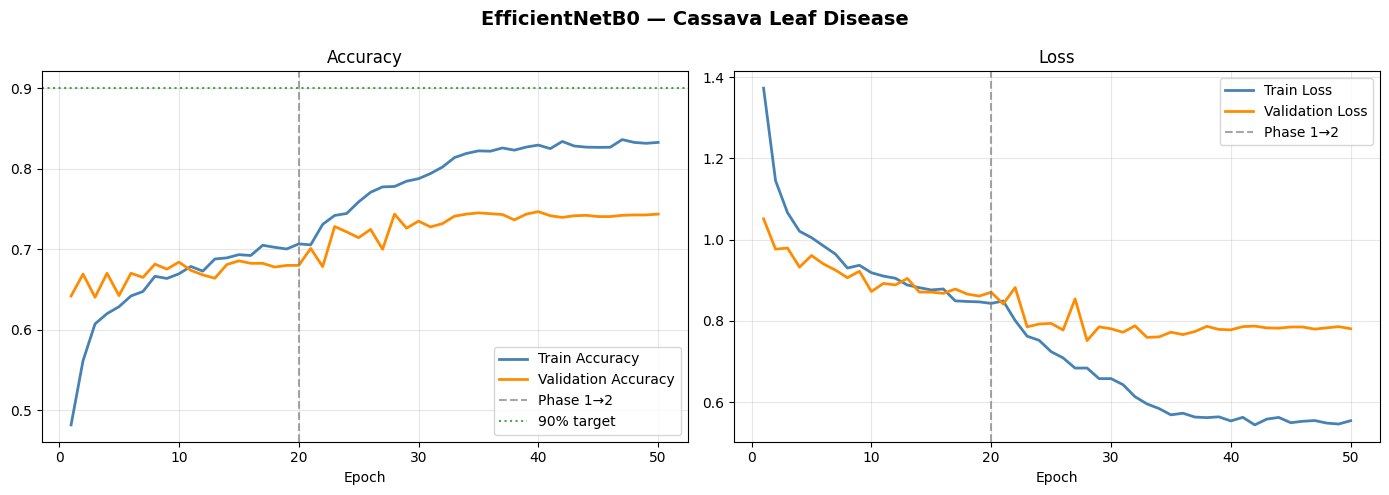

Best val_accuracy overall: 74.67%


In [35]:
acc      = history_p1.history["accuracy"]     + history_p2.history["accuracy"]
val_acc  = history_p1.history["val_accuracy"] + history_p2.history["val_accuracy"]
loss     = history_p1.history["loss"]         + history_p2.history["loss"]
val_loss = history_p1.history["val_loss"]     + history_p2.history["val_loss"]
epochs   = range(1, len(acc) + 1)
p1_end   = len(history_p1.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EfficientNetB0 — Cassava Leaf Disease", fontsize=14, fontweight="bold")

ax1.plot(epochs, acc,     label="Train Accuracy",      color="steelblue", linewidth=2)
ax1.plot(epochs, val_acc, label="Validation Accuracy", color="darkorange", linewidth=2)
ax1.axvline(x=p1_end, color="gray",  linestyle="--", alpha=0.7, label="Phase 1→2")
ax1.axhline(y=0.90,   color="green", linestyle=":",  alpha=0.7, label="90% target")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, loss,     label="Train Loss",      color="steelblue", linewidth=2)
ax2.plot(epochs, val_loss, label="Validation Loss", color="darkorange", linewidth=2)
ax2.axvline(x=p1_end, color="gray", linestyle="--", alpha=0.7, label="Phase 1→2")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history_b0.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best val_accuracy overall: {max(val_acc)*100:.2f}%")

## 10. Save Final Model

In [36]:
model.save("cassava_efficientnetb0_final.keras")
print("✓ Model saved: cassava_efficientnetb0_final.keras")

✓ Model saved: cassava_efficientnetb0_final.keras


c:\Users\Alfred\.conda\envs\pig_disease_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


61/61 ━━━━━━━━━━━━━━━━━━━━ 61s 929ms/step
                                precision    recall  f1-score   support

Cassava___brown_streak_disease       0.89      0.72      0.80       490
        Cassava___green_mottle       0.81      0.59      0.68       477
             Cassava___healthy       0.58      0.91      0.71       489
      Cassava___mosaic_disease       0.86      0.76      0.80       490

                      accuracy                           0.75      1946
                     macro avg       0.79      0.75      0.75      1946
                  weighted avg       0.79      0.75      0.75      1946



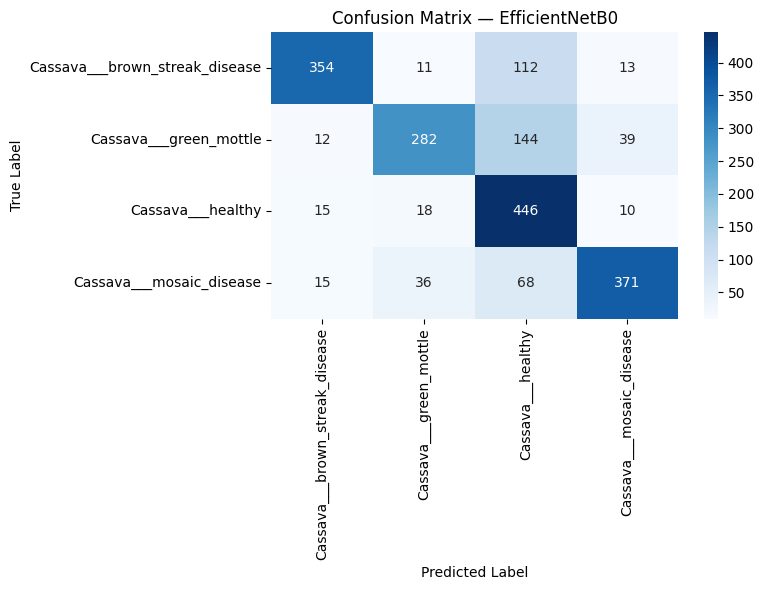

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input  

# ── Get true labels and predictions from val set ───────────────────────────────
model = tf.keras.models.load_model("cassava_b0_best_phase2.keras")  

val_data.reset()
y_pred_probs = model.predict(val_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# ── Classification Report ──────────────────────────────────────────────────────
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Confusion Matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — EfficientNetB0") 
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_b0.png", dpi=150)  
plt.show()
